# Cluster analysis(for zeta order)

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from config import paths

traj = paths.get_trajectory_path
figto = paths.get_figure_path
data = paths.get_data_path

In [2]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['font.size'] = 12
%matplotlib inline
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.spatial import ConvexHull

import os
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from collections import defaultdict
from math import ceil

from tools.custom_hbond_analysis import HydrogenBondAnalysis as HBA
from tools.zeta_order_parameter import ZetaOrderParameter as ZOP
from tools.zeta_cluster_analysis import ZetaClusterAnalysis  as ZCA

os.makedirs(figto("cluster_plots"), exist_ok=True) 

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def wrap_positions_orthorhombic(positions, box):
    """
    Wrap positions into the primary box.
    Assumes an orthorhombic box: box[:3] = [Lx, Ly, Lz].
    """
    wrapped = positions.copy()
    wrapped[:, 0] = np.mod(wrapped[:, 0], box[0])
    wrapped[:, 1] = np.mod(wrapped[:, 1], box[1])
    wrapped[:, 2] = np.mod(wrapped[:, 2], box[2])
    return wrapped


def build_frame_to_row(frames):
    """Map absolute trajectory frame number -> row index in results arrays."""
    return {int(f): i for i, f in enumerate(frames)}


# ------------------------------------------------------------
# 1) Scatter-style zeta maps for several frames
# ------------------------------------------------------------

def plot_zeta_slice_scatter_series(
    zop,
    test_frames,
    z_range=(20.0, 30.0),
    cmap="coolwarm",
    s=18,
    figsize_per_panel=(4.8, 4.8),
    percentile_clip=(2, 98),
    field_matrix=None,
    field_label=r"$\zeta$ (Å)",
):
    """
    Plot zeta maps in the XY plane for a selected Z slice.

    Parameters
    ----------
    zop : ZetaOrderParameter
        Completed ZOP object.
    test_frames : list[int]
        Absolute trajectory frame numbers, e.g. [0,160,400,...]
    z_range : tuple[float, float]
        Z slice in Å, e.g. (20, 30)
    field_matrix : np.ndarray or None
        If None, use zop.results.zeta.
        If provided, it must have shape (n_frames, n_central) aligned with zop.frames.
        This is useful for plotting zeta_cg instead of raw zeta.
    """
    if field_matrix is None:
        field_matrix = zop.results.zeta

    frame_to_row = build_frame_to_row(zop.frames)

    # Use one global color range for all panels so the comparison is meaningful.
    vmin, vmax = np.nanpercentile(field_matrix, percentile_clip)

    n_panels = len(test_frames)
    ncols = min(3, n_panels)
    nrows = ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        constrained_layout=True
    )
    axes = np.atleast_1d(axes).ravel()

    last_sc = None
    zmin, zmax = z_range

    for ax, frame in zip(axes, test_frames):
        if frame not in frame_to_row:
            ax.set_axis_off()
            ax.set_title(f"Frame {frame}\n(not analysed)")
            continue

        row = frame_to_row[frame]

        # positions are taken from the trajectory at this exact frame
        data = zop.spatial_zeta_map(frame)
        pos = data["positions"]
        values = field_matrix[row]

        # current box
        box = zop.u.trajectory.ts.dimensions.copy()
        pos = wrap_positions_orthorhombic(pos, box)

        mask = (
            (pos[:, 2] >= zmin) &
            (pos[:, 2] <  zmax) &
            np.isfinite(values)
        )

        if np.any(mask):
            last_sc = ax.scatter(
                pos[mask, 0], pos[mask, 1],
                c=values[mask],
                cmap=cmap,
                s=s,
                vmin=vmin,
                vmax=vmax
            )

        time_ps = zop.results.times[row]
        ax.set_title(f"Frame {frame}  |  t = {time_ps:.3f} ps\nslice count = {mask.sum()}")
        ax.set_xlabel("X (Å)")
        ax.set_ylabel("Y (Å)")
        ax.set_xlim(0, box[0])
        ax.set_ylim(0, box[1])
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25)

    # Hide unused axes
    for ax in axes[len(test_frames):]:
        ax.set_axis_off()

    if last_sc is not None:
        cbar = fig.colorbar(last_sc, ax=axes[:len(test_frames)], shrink=0.92)
        cbar.set_label(field_label)

    fig.suptitle(f"XY map in Z slice [{zmin}, {zmax}) Å", y=1.02, fontsize=14)
    plt.show()


# ------------------------------------------------------------
# 2) True binned heatmap for several frames
# ------------------------------------------------------------

def plot_zeta_slice_binned_series(
    zop,
    test_frames,
    z_range=(20.0, 30.0),
    bins=(60, 60),
    cmap="coolwarm",
    figsize_per_panel=(5.0, 4.6),
    percentile_clip=(2, 98),
    field_matrix=None,
    field_label=r"mean $\zeta$ (Å)",
):
    """
    Plot a true 2D heatmap by binning the XY plane and averaging zeta inside each bin.
    Better than scatter when you want a smoother field-like view.
    """
    if field_matrix is None:
        field_matrix = zop.results.zeta

    frame_to_row = build_frame_to_row(zop.frames)
    vmin, vmax = np.nanpercentile(field_matrix, percentile_clip)

    n_panels = len(test_frames)
    ncols = min(3, n_panels)
    nrows = ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        constrained_layout=True
    )
    axes = np.atleast_1d(axes).ravel()

    last_im = None
    zmin, zmax = z_range

    for ax, frame in zip(axes, test_frames):
        if frame not in frame_to_row:
            ax.set_axis_off()
            ax.set_title(f"Frame {frame}\n(not analysed)")
            continue

        row = frame_to_row[frame]
        data = zop.spatial_zeta_map(frame)
        pos = data["positions"]
        values = field_matrix[row]

        box = zop.u.trajectory.ts.dimensions.copy()
        pos = wrap_positions_orthorhombic(pos, box)

        mask = (
            (pos[:, 2] >= zmin) &
            (pos[:, 2] <  zmax) &
            np.isfinite(values)
        )

        x = pos[mask, 0]
        y = pos[mask, 1]
        v = values[mask]

        if len(v) == 0:
            ax.set_axis_off()
            ax.set_title(f"Frame {frame}\n(no valid molecules in slice)")
            continue

        # Weighted mean in each XY bin
        sum_map, xedges, yedges = np.histogram2d(
            x, y,
            bins=bins,
            range=[[0, box[0]], [0, box[1]]],
            weights=v
        )
        cnt_map, _, _ = np.histogram2d(
            x, y,
            bins=bins,
            range=[[0, box[0]], [0, box[1]]]
        )

        mean_map = np.divide(
            sum_map,
            cnt_map,
            out=np.full_like(sum_map, np.nan, dtype=float),
            where=(cnt_map > 0)
        )

        last_im = ax.pcolormesh(
            xedges, yedges, mean_map.T,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto"
        )

        time_ps = zop.results.times[row]
        ax.set_title(f"Frame {frame}  |  t = {time_ps:.3f} ps\nslice count = {mask.sum()}")
        ax.set_xlabel("X (Å)")
        ax.set_ylabel("Y (Å)")
        ax.set_xlim(0, box[0])
        ax.set_ylim(0, box[1])
        ax.set_aspect("equal", adjustable="box")

    for ax in axes[len(test_frames):]:
        ax.set_axis_off()

    if last_im is not None:
        cbar = fig.colorbar(last_im, ax=axes[:len(test_frames)], shrink=0.92)
        cbar.set_label(field_label)

    fig.suptitle(f"Binned XY heatmap in Z slice [{zmin}, {zmax}) Å", y=1.02, fontsize=14)
    plt.show()

In [4]:
u = mda.Universe(traj("tip4p-ice-225K.data"),traj("traj_5e-6_225_100000.lammpstrj"),format="LAMMPSDUMP",dt=0.025)

hba = HBA(
    universe=u,
    donors_sel="type 1",
    hydrogens_sel="type 2",
    acceptors_sel="type 1",
    d_a_cutoff=3.5,          # Å – donor-to-acceptor heavy-atom distance
    h_d_a_angle_cutoff=30.0, # °  – angle at the donor (H-D-A < 30°)
    update_selections=False, # Set True for flexible / protein systems
)

# ---- Run --------------------------------------------------------------------
# start/stop/step follow MDAnalysis convention (frame indices, not time).
# Omit them to analyse every frame.
hba.run()

In [5]:
# ---- Zeta analysis ----------------------------------------------------------
# shell_cutoff > d_a_cutoff to ensure at least one non-HB neighbor is found.
# 6.0 Å spans comfortably into the first-shell / second-shell boundary in water.
zop = ZOP(
    hba=hba,
    central_sel="type 1",
    shell_cutoff=6.0,
)
zop.run(verbose=True)
 
times_ps        = zop.results.times          # shape (n_frames,)
central_indices = zop.results.central_indices  # OW atom indices

100%|██████████| 4001/4001 [14:01<00:00,  4.76it/s]


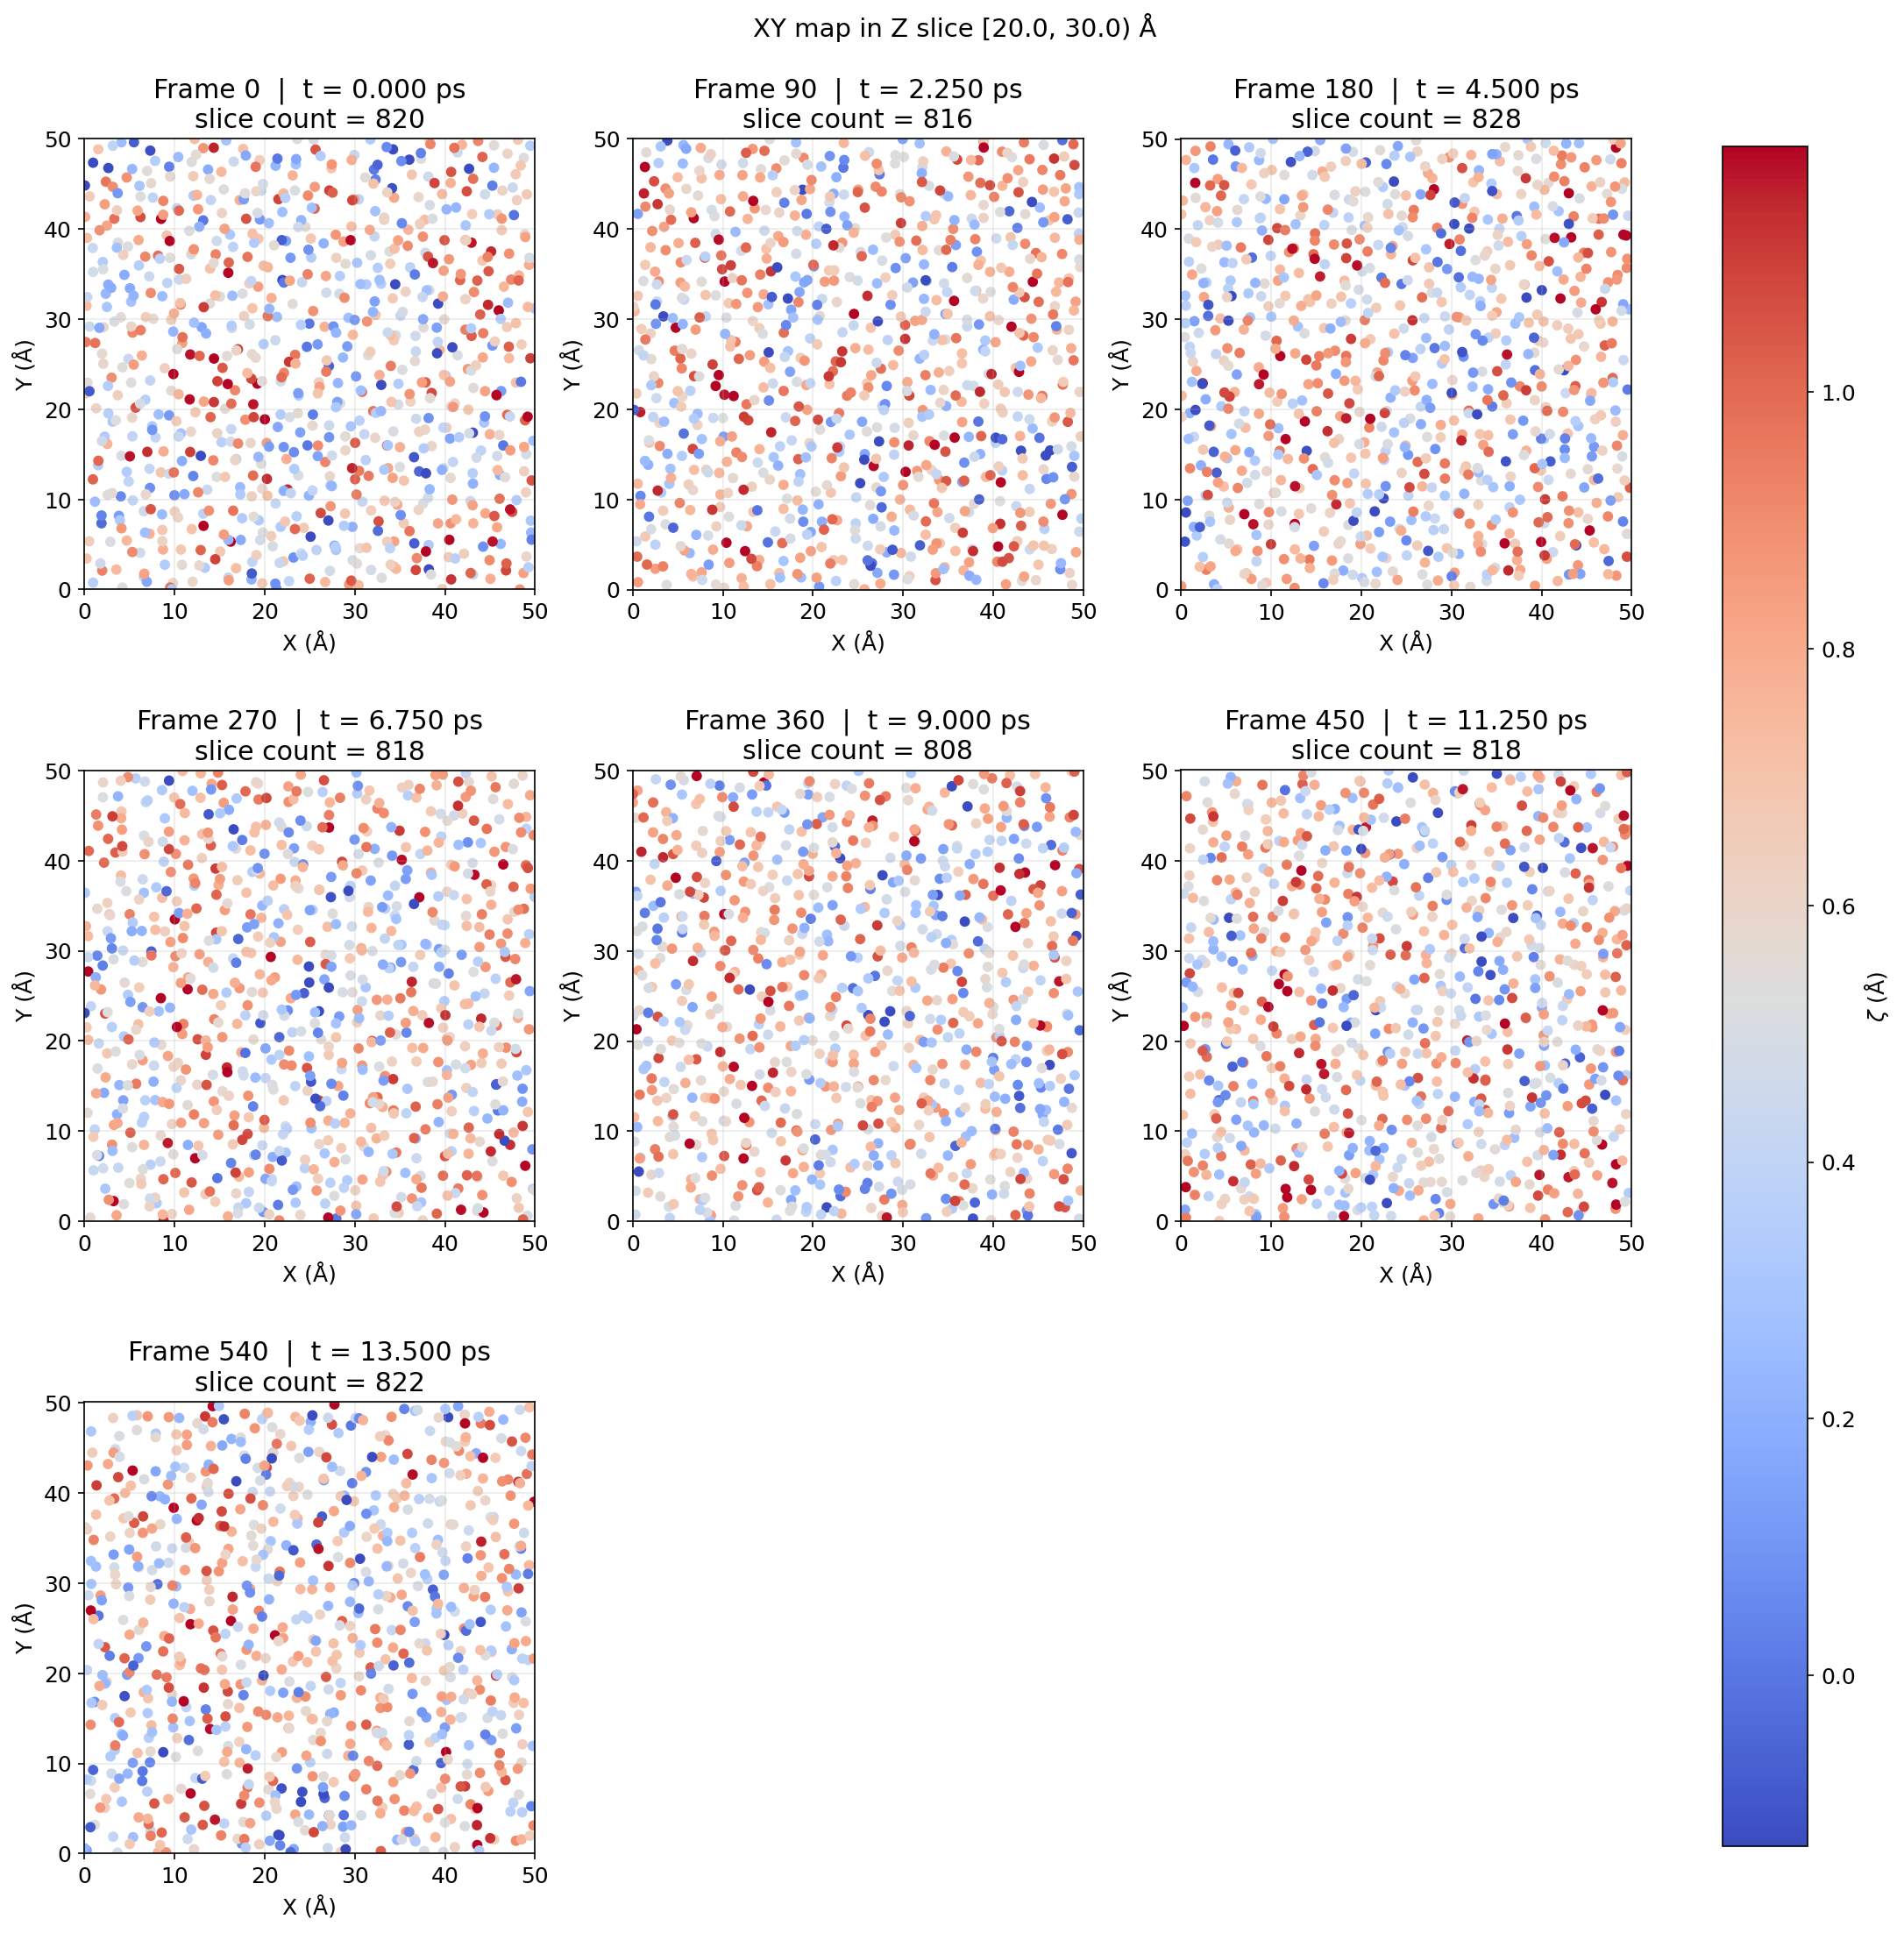

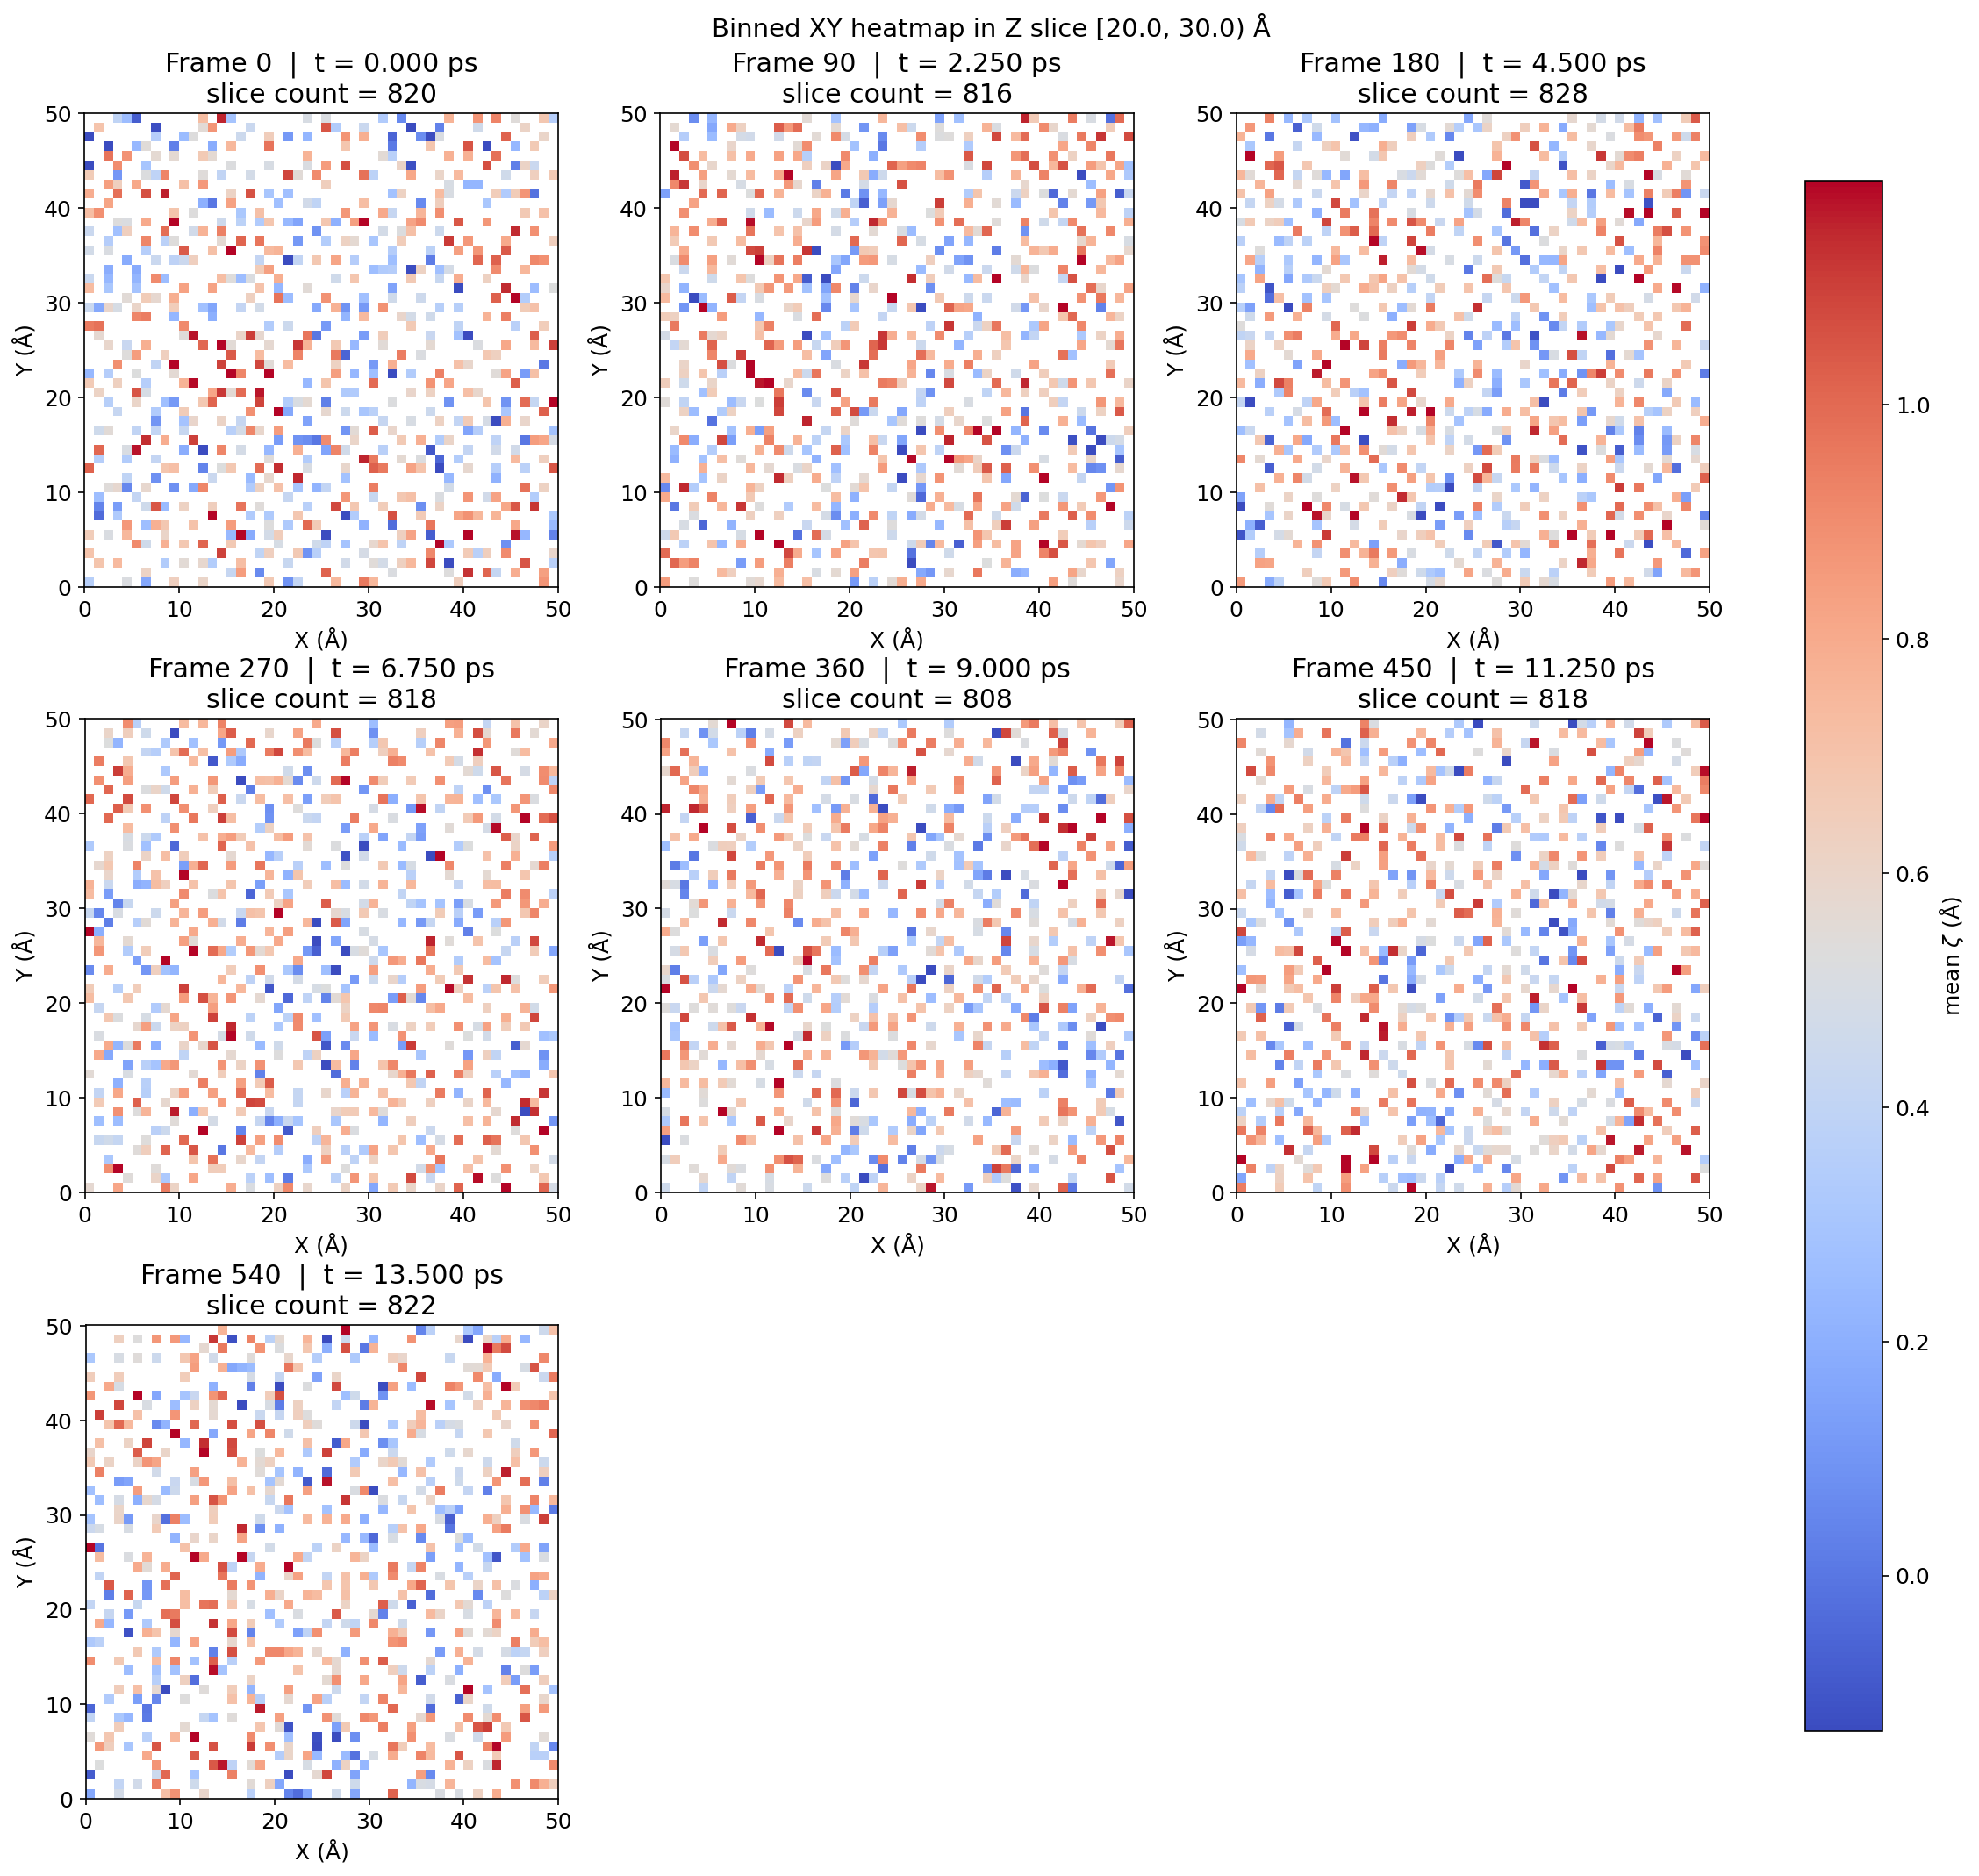

In [6]:
test_frames = [0, 90, 180, 270, 360, 450, 540]

# Scatter version: closest to your current plotting style
plot_zeta_slice_scatter_series(
    zop,
    test_frames=test_frames,
    z_range=(20.0, 30.0),
    s=22
)

# True heatmap version: better if you want a smoother spatial field
plot_zeta_slice_binned_series(
    zop,
    test_frames=test_frames,
    z_range=(20.0, 30.0),
    bins=(50, 50)
)

In [7]:
def compute_propensity_3d_from_ensemble(
    traj_positions,   # shape: (n_traj, n_frames, N, 3)
    gamma_dot,
    dt_ps=0.025,
    end_frame=360,
):
    """
    traj_positions[k, n, i, a]:
        trajectory k, frame n, molecule i, Cartesian component a
    Uses the user's chosen affine subtraction:
        dx_aff = gamma_dot * dt * sum_n y_n
    """

    n_traj, _, n_mol, _ = traj_positions.shape
    dr2_all = np.zeros((n_traj, n_mol), dtype=float)

    for k in range(n_traj):
        pos = traj_positions[k]

        r0 = pos[0]                 # (N, 3)
        rt = pos[end_frame]         # (N, 3)

        # user's chosen discrete affine correction
        y_series = pos[:end_frame + 1, :, 1]   # include frames 0..end_frame
        dx_aff = gamma_dot * dt_ps * np.sum(y_series, axis=0)

        dx_na = (rt[:, 0] - r0[:, 0]) - dx_aff
        dy    =  rt[:, 1] - r0[:, 1]
        dz    =  rt[:, 2] - r0[:, 2]

        dr2_all[k] = dx_na**2 + dy**2 + dz**2

    P3D = np.mean(dr2_all, axis=0)
    return P3D, dr2_all

In [ ]:
# zeta map at the reference frame, usually frame 0
zmap = zop.spatial_zeta_map(frame=0)
coords0 = zmap["positions"]      # (N, 3)
zeta0   = zmap["zeta"]           # (N,)

# iso-configurational propensity over one characteristic time
P3D, _ = compute_propensity_3d_from_ensemble(
    traj_positions=traj_positions,
    gamma_dot=gamma_dot,
    dt_ps=0.025,
    end_frame=360,
)

# same slice rule as zeta heatmap
mask = (
    (coords0[:, 2] > 20.0) &
    (coords0[:, 2] < 30.0) &
    np.isfinite(zeta0) &
    np.isfinite(P3D)
)